In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math



In [3]:
df = pd.read_csv("../data/application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
nulls=df.isna().sum()
nulls.head()
nulls.to_csv("dumps_from_notebooks/nullsPerColumn",index=False)
porcentaje_of_nulls = (nulls * 100) / len(df)
porcentaje_of_nulls.head()
porcentaje_of_nulls.to_csv("dumps_from_notebooks/porcentajeOfNullsPerColumn",index=False)

print(len(df))

307511


In [ ]:

#now we will explore the hypothesis of train one model per type of contract. Starting for how viable is with the data available

print(df["NAME_CONTRACT_TYPE"].value_counts(normalize=True) * 100)
print(df.groupby("NAME_CONTRACT_TYPE")["TARGET"].mean() * 100)

#Considering the volume of the minoritary class (less than 10%) and their event ratio (5%) seems not ideal have to separate the models.



NAME_CONTRACT_TYPE
Cash loans         90.478715
Revolving loans     9.521285
Name: proportion, dtype: float64
NAME_CONTRACT_TYPE
Cash loans         8.345913
Revolving loans    5.478329
Name: TARGET, dtype: float64


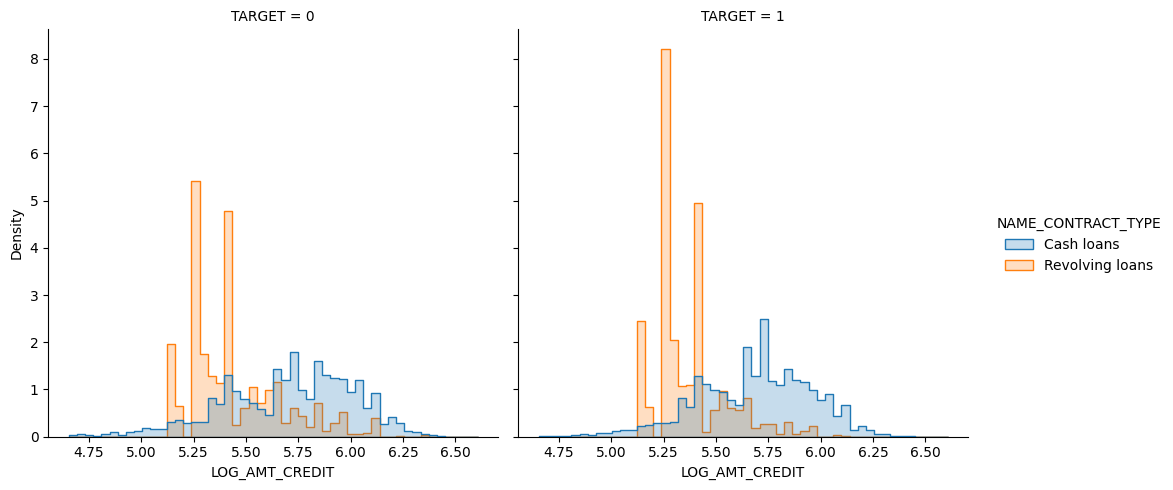

In [ ]:
#here i want to check if the main variables that describes the loan change their distribution and trending between the type of contract,
#and also see how much change in the case of default. 

df["LOG_AMT_CREDIT"]= np.log10(df["AMT_CREDIT"])

g = sns.displot(
    data=df,
    x="LOG_AMT_CREDIT",
    hue="NAME_CONTRACT_TYPE",
    bins=50,
    element="step",
    stat="density",
    col="TARGET",
    common_norm=False
)

for ax in g.axes.flat:
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')


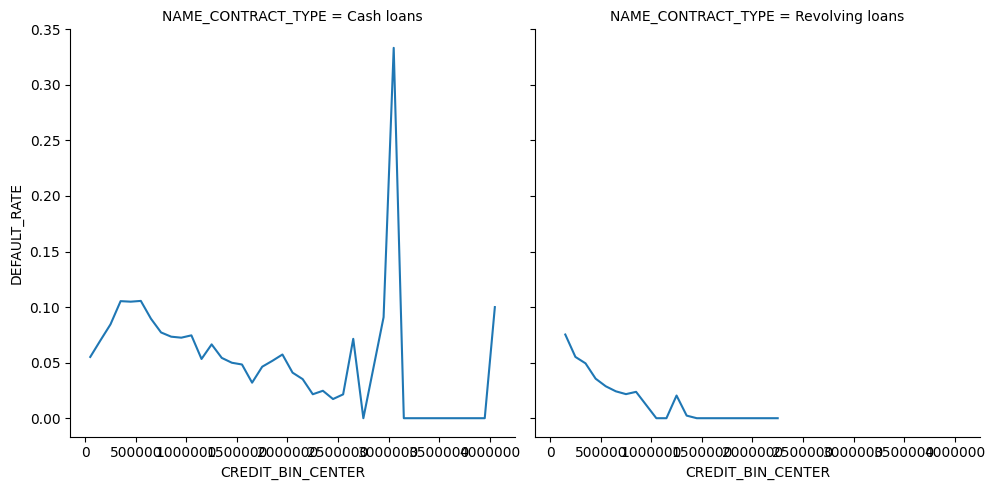

In [21]:
bins= np.arange(0,df["AMT_CREDIT"].max() + 100000, 100000)
df["BINED_AMT_CREDIT"]=  pd.cut(df["AMT_CREDIT"],bins=bins)
df_groupBy_bins = df.groupby(["BINED_AMT_CREDIT","NAME_CONTRACT_TYPE"],observed=True)["TARGET"].mean().reset_index(name="DEFAULT_RATE")
df_groupBy_bins["CREDIT_BIN_CENTER"] = df_groupBy_bins["BINED_AMT_CREDIT"].apply(lambda x: x.mid)
gr=sns.relplot(data=df_groupBy_bins,x="CREDIT_BIN_CENTER",y="DEFAULT_RATE",kind="line",col="NAME_CONTRACT_TYPE")

for ax in gr.axes.flat:
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')




<Axes: xlabel='LOG_AMT_CREDIT', ylabel='Density'>

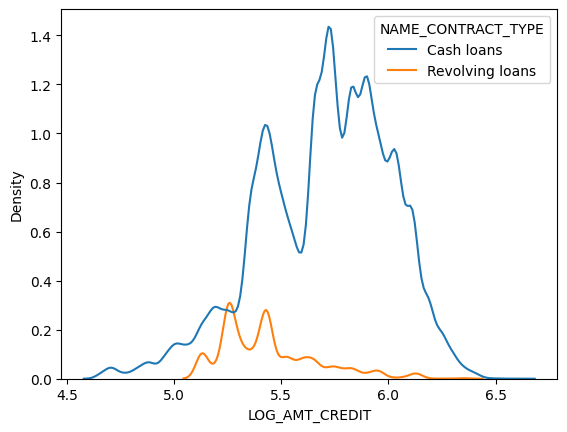

In [21]:
sns.kdeplot(data=df, x="LOG_AMT_CREDIT", hue="NAME_CONTRACT_TYPE")